In [ ]:
import duckdb
from functions.evaluation import evaluate
from networks.cnn_dilated_convolutions import CNNModel
from networks.cnn_network import build_dataloaders


con = duckdb.connect('../capillary.db')
df = con.execute(""" 
                 SELECT id, value,fractions, boundaries,albumin,antitrypsin,orosomukoid,haptoglobin,crp,igg,iga,igm, label, set, interpretation
                 FROM protein_data
                 WHERE value IS NOT NULL
                 AND observation_nr = 1
                 AND analysis IS NOT NULL
                 AND protein_value IS NOT NULL
                 """).df()
con.close()

df = df[
    (df['fractions'].apply(len) == 6) &
    (df['boundaries'].apply(len) == 12)
]

train_rows = df[df['set'] == 'train']
val_rows   = df[df['set'] == 'val']
test_rows  = df[df['set'] == 'test']

drop_indices = train_rows[train_rows['label'] == 0].sample(frac=0.5).index


train_rows = train_rows.drop(drop_indices)
train_rows = train_rows[train_rows['label'].isin([0,1])]
val_rows = val_rows[val_rows['label'].isin([0,1])]

print(f"Antal utan m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 0])}")
print(f"Antal med m-komponent i träningsdatan: {len(train_rows[train_rows['label'] == 1])}")

CNN = CNNModel()
cnn_train_dl, cnn_val_dl, _ = build_dataloaders(train_rows, val_rows, val_rows)
CNN.retrain(cnn_train_dl,cnn_val_dl,patience=15)

Antal utan m-komponent i träningsdatan: 30492
Antal med m-komponent i träningsdatan: 4730
Epoch   0 | train: 0.6784 | val: 0.5603 | acc: 91.69% | AUC: 0.751
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   1 | train: 0.5332 | val: 0.4817 | acc: 82.22% | AUC: 0.827
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   2 | train: 0.4618 | val: 0.4349 | acc: 86.63% | AUC: 0.872
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   3 | train: 0.3970 | val: 0.3689 | acc: 88.22% | AUC: 0.918
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   4 | train: 0.3439 | val: 0.2914 | acc: 92.12% | AUC: 0.955
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   5 | train: 0.3037 | val: 0.2494 | acc: 94.28% | AUC: 0.957
  -> ny bästa modell sparad till ../models/convolution_dilated_version.pth
Epoch   6 | train: 0.2616 | val: 0.2289 | acc: 92.90% | AU

              precision    recall  f1-score   support

     Negativ       0.99      0.98      0.99      7146
     Positiv       0.78      0.90      0.84       586

    accuracy                           0.97      7732
   macro avg       0.89      0.94      0.91      7732
weighted avg       0.98      0.97      0.97      7732

[[7001  145]
 [  58  528]]
AUC: 0.9861246034679894
Accuracy:  97.37%
FN-rate:   9.90%  (farliga missade fall)
FP-rate:   2.03%  (onödiga larm)
Sensitivitet:   90.10%  (Sannolikhet att upptäcka ett positivt fall)
Specificitet:   97.97%  (Sannolikhet att korrekt klassificera ett negativt fall negativt)
AUC: 0.9861


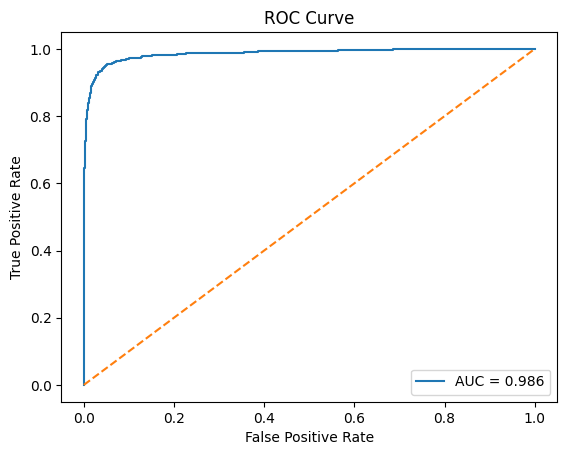

In [3]:
test_rows = test_rows[test_rows['label'].isin([0,1])]
result = CNN.predict(test_rows)
_ = evaluate(result,threshold=0.5,proportion=70)